# BFOR515 Group Project — Transit Ridership: NYC vs Philadelphia

This notebook analyzes monthly public transit ridership between New York City (MTA) and Philadelphia (SEPTA). We examine ridership trends across three transit modes — **Bus, Subway, and Rail** — from 2021 to 2025, using  statistics, visualizations, hypothesis testing, and linear regression.

---
## Section 1 — Data Recap & Preparation

### Datasets Used
- **NYC MTA Dataset**: Monthly ridership by transit mode from January 2021 to December 2025.
- **Philadelphia SEPTA Dataset**: Average daily ridership by transit mode from 2019 to 2025.
### Cleaning Decisions

**1. Standardizing transit modes:** Both cities use different names for similar services. We unified all modes into three categories:
- **Bus** — includes NYC Access-A-Ride, Demand Response; Philly CCT, Trackless Trolley
- **Subway** — includes Philly Heavy Rail and Trolley
- **Rail** — includes NYC Long Island Rail Road, Metro-North; Philly Regional Rail

**2. Dropping NYC water ferries:** Philadelphia has no such transit data, so NYC ferry data was excluded.

**3. Converting Philly ridership to monthly totals:** The original SEPTA dataset provides *average daily ridership*, on the other hand, the MTA dataset provides *total monthly ridership*. To make both datasets comparable, we multiplied Philly's daily average by the actual number of days in each month using Python's `calendar` module.

**4. Standardizing column names and date format:** Both dataframes changed to the same four columns: `month_year`, `mode`, `ridership`, `city`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import calendar

# NYC dataset
nyc_df = pd.read_csv("MTAridership.csv")
print(nyc_df.head())

# Philadelphia dataset
phil_df = pd.read_csv("SEPTAridership.csv")
print(phil_df.head())

     Month Transit Operator                   Mode  Ridership
0  12/1/25              MTA          Access-A-Ride    1348149
1  12/1/25              MTA                    Bus   32749591
2  12/1/25              MTA  Long Island Rail Road    7198359
3  12/1/25              MTA   Metro-North Railroad    6103890
4  12/1/25              MTA                 Subway  110534936
   Calendar_Year  Calendar_Month               Mode  Average_Daily_Ridership  \
0           2019               1                Bus                   459160   
1           2019               1                CCT                     4294   
2           2019               1         Heavy Rail                   296709   
3           2019               1      Regional Rail                   122856   
4           2019               1  Trackless Trolley                    16853   

    Source  ObjectId  
0      APC         1  
1  Revenue         2  
2  Revenue         3  
3  Revenue         4  
4      APC         5  


In [ ]:
# NYC data cleaning
# make column names lowercase and "_" separated
nyc_df.columns = nyc_df.columns.str.lower().str.strip().str.replace(" ", "_")

# Convert 'month' column to datetime
nyc_df["month"] = pd.to_datetime(nyc_df["month"])

# drop unwanted columns
nyc_df = nyc_df[["month", "mode", "ridership"]]

# create month_year column in M/YYYY format
nyc_df["month_year"] = nyc_df["month"].dt.month.astype(str) + "/" + nyc_df["month"].dt.year.astype(str)

# drop unwanted columns
nyc_df = nyc_df[["month_year", "mode", "ridership"]]

# Add city column to compare
nyc_df["city"] = "NYC"

print(nyc_df.head())

nyc_df["mode"].value_counts()

  month_year                   mode  ridership city
0    12/2025          Access-A-Ride    1348149  NYC
1    12/2025                    Bus   32749591  NYC
2    12/2025  Long Island Rail Road    7198359  NYC
3    12/2025   Metro-North Railroad    6103890  NYC
4    12/2025                 Subway  110534936  NYC


/tmp/ipykernel_1219/1875197906.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  nyc_df["month"] = pd.to_datetime(nyc_df["month"])


,count
mode,
Bus,110
Access-A-Ride,60
Long Island Rail Road,60
Metro-North Railroad,60
Subway,60
Staten Island Ferry,59
New York City Ferry,58
PATH,58
Demand Response,50


In [ ]:
# NYC transit modes to just Subway, Rail, Bus
nyc_df["mode"] = nyc_df["mode"].replace({
    "Long Island Rail Road": "Rail",
    "Metro-North Railroad": "Rail",
    "Commuter Rail": "Rail",
    "Subway": "Subway",
    "Bus": "Bus",
    "Access-A-Ride": "Bus",
    "Demand Response": "Bus"
})

nyc_df = nyc_df[nyc_df["mode"].isin(["Subway", "Rail", "Bus"])]
print(nyc_df.head())

  month_year    mode  ridership city
0    12/2025     Bus    1348149  NYC
1    12/2025     Bus   32749591  NYC
2    12/2025    Rail    7198359  NYC
3    12/2025    Rail    6103890  NYC
4    12/2025  Subway  110534936  NYC


In [ ]:
# Philadelphia data cleaning
# make column names lowercase and "_"separated
phil_df.columns = phil_df.columns.str.lower().str.strip().str.replace(" ", "_")

# create month_year column in M/YYYY format
phil_df["month_year"] = phil_df["calendar_month"].astype(str) + "/" + phil_df["calendar_year"].astype(str)

# Convert average daily ridership to monthly total
phil_df["days_in_month"] = phil_df.apply(
    lambda r: calendar.monthrange(int(r["calendar_year"]), int(r["calendar_month"]))[1], axis=1
)
phil_df["ridership"] = phil_df["average_daily_ridership"] * phil_df["days_in_month"]

# drop unwanted columns
phil_df = phil_df[["month_year", "mode", "ridership"]]

# Add city column
phil_df["city"] = "Philadelphia"

phil_df["mode"].value_counts()

,count
mode,
Bus,84
CCT,84
Heavy Rail,84
Regional Rail,84
Trackless Trolley,84
Trolley,84


In [ ]:
# phil. transit modes to just Subway, Rail, Bus
phil_df["mode"] = phil_df["mode"].replace({
    "Bus": "Bus",
    "CCT": "Bus",
    "Trackless Trolley": "Bus",
    "Heavy Rail": "Subway",
    "Trolley": "Subway",
    "Regional Rail": "Rail"
})


phil_df = phil_df[phil_df["mode"].isin(["Subway", "Rail", "Bus"])]
print(phil_df.head())

  month_year    mode  ridership          city
0     1/2019     Bus   14233960  Philadelphia
1     1/2019     Bus     133114  Philadelphia
2     1/2019  Subway    9197979  Philadelphia
3     1/2019    Rail    3808536  Philadelphia
4     1/2019     Bus     522443  Philadelphia


### Cleaned Data

Before analysis, we confirm that both dataframes are clean — no missing values, correct column structure, and only the three expected transit modes.

In [ ]:
print("NYC DataFrame ")
print("Shape:", nyc_df.shape)
print("Columns:", nyc_df.columns.tolist())
print("Modes:", nyc_df["mode"].unique())
print("Null values:\n", nyc_df.isnull().sum())
print(nyc_df.head())

print("\n Philadelphia DataFrame ")
print("Shape:", phil_df.shape)
print("Columns:", phil_df.columns.tolist())
print("Modes:", phil_df["mode"].unique())
print("Null values:\n", phil_df.isnull().sum())
print(phil_df.head())

NYC DataFrame 
Shape: (450, 4)
Columns: ['month_year', 'mode', 'ridership', 'city']
Modes: ['Bus' 'Rail' 'Subway']
Null values:
 month_year    0
mode          0
ridership     0
city          0
dtype: int64
  month_year    mode  ridership city
0    12/2025     Bus    1348149  NYC
1    12/2025     Bus   32749591  NYC
2    12/2025    Rail    7198359  NYC
3    12/2025    Rail    6103890  NYC
4    12/2025  Subway  110534936  NYC

 Philadelphia DataFrame 
Shape: (504, 4)
Columns: ['month_year', 'mode', 'ridership', 'city']
Modes: ['Bus' 'Subway' 'Rail']
Null values:
 month_year    0
mode          0
ridership     0
city          0
dtype: int64
  month_year    mode  ridership          city
0     1/2019     Bus   14233960  Philadelphia
1     1/2019     Bus     133114  Philadelphia
2     1/2019  Subway    9197979  Philadelphia
3     1/2019    Rail    3808536  Philadelphia
4     1/2019     Bus     522443  Philadelphia


In [ ]:
# Combine both datasets
combined_df = pd.concat([nyc_df, phil_df], ignore_index=True)

combined_df["date"] = pd.to_datetime(combined_df["month_year"], format="%m/%Y")

# Group by date, mode, city and sum ridership
combined_df = combined_df.groupby(["date", "month_year", "mode", "city"], as_index=False)["ridership"].sum()
combined_df = combined_df.sort_values("date").reset_index(drop=True)

print("Combined DataFrame Shape:", combined_df.shape)
print(combined_df.head(20))

Combined DataFrame Shape: (432, 5)
         date month_year    mode          city  ridership
0  2019-01-01     1/2019     Bus  Philadelphia   14889517
1  2019-01-01     1/2019    Rail  Philadelphia    3808536
2  2019-01-01     1/2019  Subway  Philadelphia   11764376
3  2019-02-01     2/2019     Bus  Philadelphia   13611864
4  2019-02-01     2/2019    Rail  Philadelphia    3392508
5  2019-02-01     2/2019  Subway  Philadelphia   11162060
6  2019-03-01     3/2019     Bus  Philadelphia   15603137
7  2019-03-01     3/2019    Rail  Philadelphia    3665068
8  2019-03-01     3/2019  Subway  Philadelphia   12127510
9  2019-04-01     4/2019     Bus  Philadelphia   14924130
10 2019-04-01     4/2019    Rail  Philadelphia    3721350
11 2019-04-01     4/2019  Subway  Philadelphia   11710650
12 2019-05-01     5/2019  Subway  Philadelphia   12002859
13 2019-05-01     5/2019     Bus  Philadelphia   15660611
14 2019-05-01     5/2019    Rail  Philadelphia    3694797
15 2019-06-01     6/2019     Bus  Phi

---
## Section 2 — Exploratory Data Analysis (EDA)

We now apply statistics and create visualizations to understand ridership patterns in both cities.

### Statistics

We calculate mean, median, and standard deviation of monthly ridership. This gives us an understanding of how much each mode is used on average.

In [ ]:
# statistics by city and mode
desc_stats = combined_df.groupby(["city", "mode"])["ridership"].agg(
    Mean="mean",
    Median="median",
    Std="std",
    Min="min",
    Max="max"
).round(0)

print(desc_stats.to_string())

                           Mean      Median         Std       Min        Max
city         mode                                                           
NYC          Bus     44152671.0  45335026.0   5188547.0  28520107   55061998
             Rail    13146503.0  13502544.0   3515355.0   4151626   19470292
             Subway  90034965.0  93988464.0  17746723.0  39170408  115832938
Philadelphia Bus     10522836.0  10776369.0   2823309.0   4409790   16347447
             Rail     2074880.0   2091962.0   1018399.0     62496    4154430
             Subway   6891459.0   6802388.0   2700881.0   1776690   12605375


### Visualization 1 — Monthly Ridership Trends Over Time (by City and Mode)

This line chart shows how total monthly ridership has changed over time for each transit mode in both cities. It helps us identify recovery trends post-COVID, seasonal patterns, and overall growth or decline.

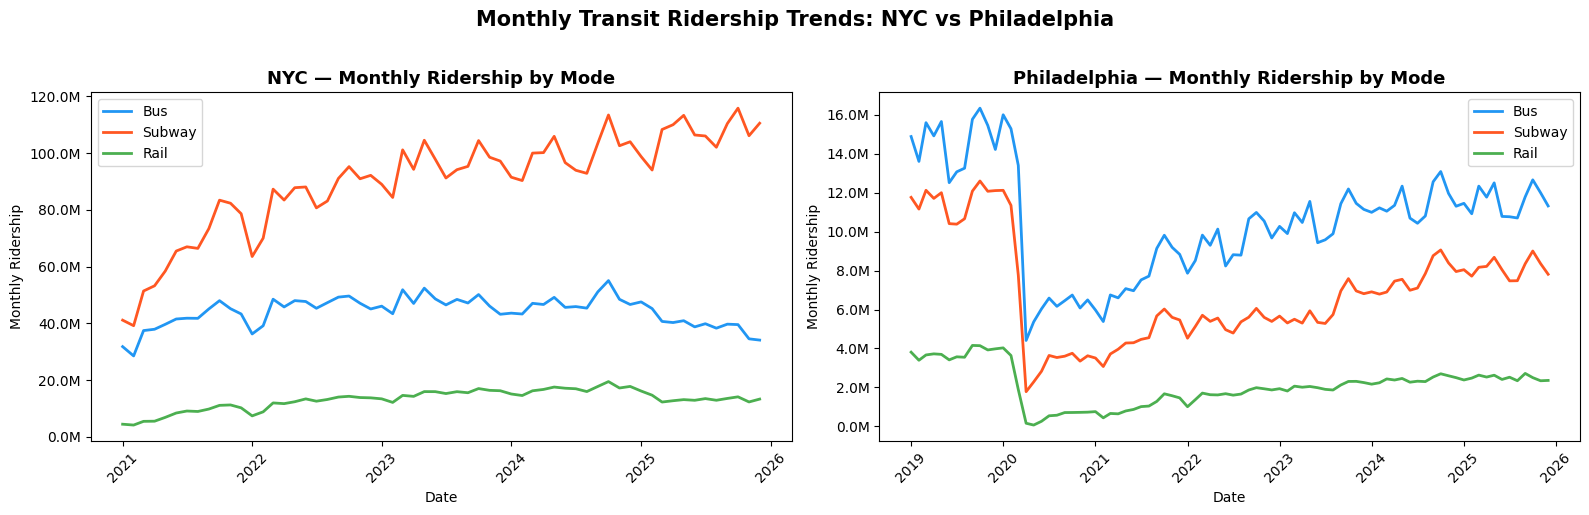

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

cities = ["NYC", "Philadelphia"]
colors = {"Bus": "#2196F3", "Subway": "#FF5722", "Rail": "#4CAF50"}

for i, city in enumerate(cities):
    city_data = combined_df[combined_df["city"] == city]
    for mode in ["Bus", "Subway", "Rail"]:
        mode_data = city_data[city_data["mode"] == mode].sort_values("date")
        axes[i].plot(mode_data["date"], mode_data["ridership"],
                     label=mode, color=colors[mode], linewidth=2)
    axes[i].set_title(f"{city} — Monthly Ridership by Mode", fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Monthly Ridership")
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.suptitle("Monthly Transit Ridership Trends: NYC vs Philadelphia", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Interpretation: NYC subway consistently dominates ridership with the highest numbers,showing a strong recovery trend from 2021 onwards. Philadelphia's ridership is lower in scale but shows similar recovery patterns. Both cities show slight dips in winter months, suggesting seasonal variation. Bus ridership is the second highest in NYC while in Philadelphia the modes are more evenly distributed.

### Visualization 2 — Average Monthly Ridership by Mode (NYC vs Philadelphia)

This bar chart directly compares the average monthly ridership for all transit mode between the two cities, making it easy to see which modes are most used and how the cities differ.

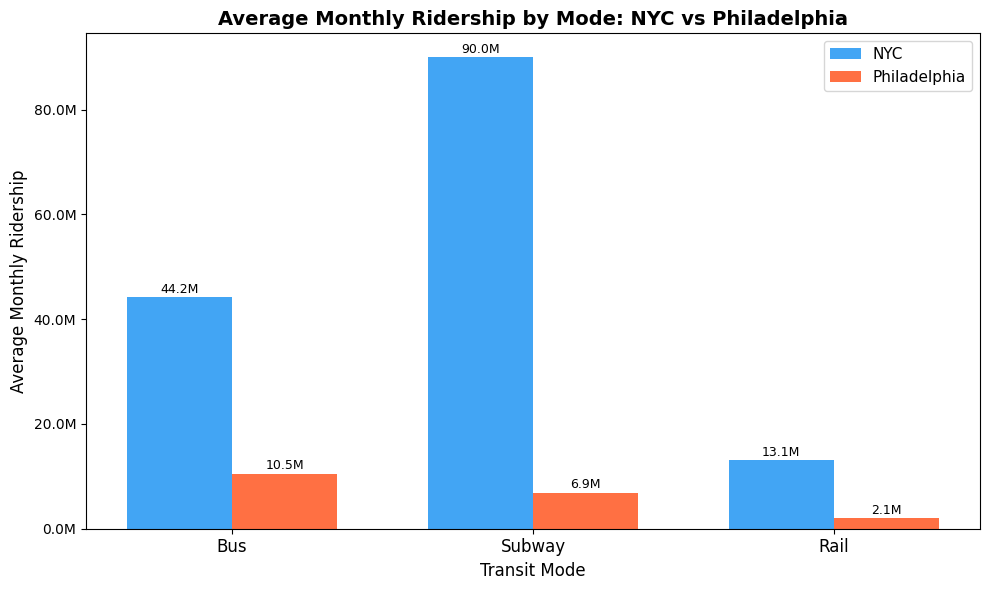

In [ ]:
avg_by_mode = combined_df.groupby(["city", "mode"])["ridership"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

modes = ["Bus", "Subway", "Rail"]
x = np.arange(len(modes))
width = 0.35

nyc_vals = [avg_by_mode[(avg_by_mode["city"]=="NYC") & (avg_by_mode["mode"]==m)]["ridership"].values[0]
            if len(avg_by_mode[(avg_by_mode["city"]=="NYC") & (avg_by_mode["mode"]==m)]) > 0 else 0
            for m in modes]
phil_vals = [avg_by_mode[(avg_by_mode["city"]=="Philadelphia") & (avg_by_mode["mode"]==m)]["ridership"].values[0]
             if len(avg_by_mode[(avg_by_mode["city"]=="Philadelphia") & (avg_by_mode["mode"]==m)]) > 0 else 0
             for m in modes]

bars1 = ax.bar(x - width/2, nyc_vals, width, label='NYC', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, phil_vals, width, label='Philadelphia', color='#FF5722', alpha=0.85)

ax.set_xlabel('Transit Mode', fontsize=12)
ax.set_ylabel('Average Monthly Ridership', fontsize=12)
ax.set_title('Average Monthly Ridership by Mode: NYC vs Philadelphia', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modes, fontsize=12)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

for bar in bars1:
    ax.annotate(f'{bar.get_height()/1e6:.1f}M', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height()/1e6:.1f}M', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()



Interpretation: NYC ridership is significantly higher across all modes due to its larger
population. The subway is by far the most used mode in NYC. In Philadelphia, the gap
between modes is much smaller, suggesting a more distributed use of transit options.
Rail usage is proportionally higher in Philadelphia compared to NYC.

### Visualization 3 — Ridership Distribution by Mode (Boxplot)

This boxplot shows the spread and variability of monthly ridership for each mode in both cities. It helps us see outliers, consistency, and how ridership varies month to month.

/tmp/ipykernel_1219/2735585286.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=city_data, x="mode", y="ridership",
/tmp/ipykernel_1219/2735585286.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=city_data, x="mode", y="ridership",


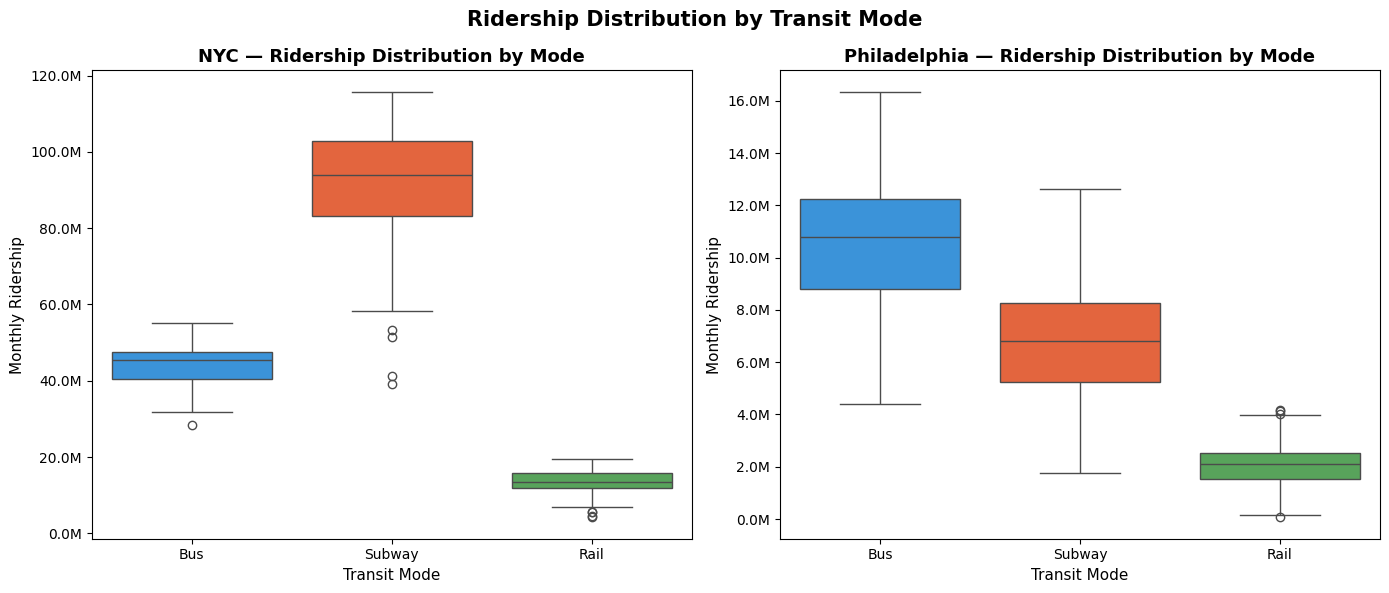

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

for i, city in enumerate(["NYC", "Philadelphia"]):
    city_data = combined_df[combined_df["city"] == city]
    sns.boxplot(data=city_data, x="mode", y="ridership",
                palette={"Bus": "#2196F3", "Subway": "#FF5722", "Rail": "#4CAF50"},
                ax=axes[i], order=["Bus", "Subway", "Rail"])
    axes[i].set_title(f"{city} — Ridership Distribution by Mode", fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Transit Mode", fontsize=11)
    axes[i].set_ylabel("Monthly Ridership", fontsize=11)
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.suptitle("Ridership Distribution by Transit Mode", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


Interpretation: The boxplots reveal that NYC subway ridership has the widest spread,
indicating high variability month to month likely due to seasonal and pandemic-related
changes. Philadelphia shows tighter distributions across all modes, suggesting more
stable ridership patterns. Outliers in both cities likely correspond to COVID-affected
months in 2021.

---
## Section 3 — Core Analysis

We use two analytical methods: **Hypothesis Testing (T-Test)** and **Linear Regression**. These methods help us determine whether ridership differences between cities are statistically significant and whether ridership is trending over time.

### Method 1 — Hypothesis Testing (Independent T-Test)

**Why we chose this:** Our research question asks whether there is a meaningful difference in ridership between NYC and Philadelphia for each transit mode. A t-test lets us determine whether observed differences are statistically significant or could have occurred by chance.

- **Null Hypothesis (H₀):** There is no significant difference in monthly ridership between NYC and Philadelphia for a given mode.
- **Alternative Hypothesis (H₁):** There is a significant difference in monthly ridership between the two cities.
- **Significance level:** α = 0.05

In [ ]:
# Filter to overlapping date range for fair comparison (2021 onwards)
nyc_analysis = combined_df[(combined_df["city"] == "NYC") & (combined_df["date"].dt.year >= 2021)]
phil_analysis = combined_df[(combined_df["city"] == "Philadelphia") & (combined_df["date"].dt.year >= 2021)]

print(" Independent T-Test Results: NYC vs Philadelphia Ridership by Mode \n")

for mode in ["Bus", "Subway", "Rail"]:
    nyc_mode = nyc_analysis[nyc_analysis["mode"] == mode]["ridership"].dropna()
    phil_mode = phil_analysis[phil_analysis["mode"] == mode]["ridership"].dropna()

    t_stat, p_val = stats.ttest_ind(nyc_mode, phil_mode)

    print(f"Mode: {mode}")
    print(f"  NYC Mean:          {nyc_mode.mean():>15,.0f}")
    print(f"  Philadelphia Mean: {phil_mode.mean():>15,.0f}")
    print(f"  T-Statistic:       {t_stat:>15.4f}")
    print(f"  P-Value:           {p_val:>15.6f}")
    conclusion = "REJECT H₀ — Significant difference" if p_val < 0.05 else "FAIL TO REJECT H₀ — No significant difference"
    print(f"  Conclusion:        {conclusion}")
    print()

 Independent T-Test Results: NYC vs Philadelphia Ridership by Mode 

Mode: Bus
  NYC Mean:               44,152,671
  Philadelphia Mean:      10,158,859
  T-Statistic:               47.9717
  P-Value:                  0.000000
  Conclusion:        REJECT H₀ — Significant difference

Mode: Subway
  NYC Mean:               90,034,965
  Philadelphia Mean:       6,335,817
  T-Statistic:               36.3978
  P-Value:                  0.000000
  Conclusion:        REJECT H₀ — Significant difference

Mode: Rail
  NYC Mean:               13,146,503
  Philadelphia Mean:       1,921,589
  T-Statistic:               24.3875
  P-Value:                  0.000000
  Conclusion:        REJECT H₀ — Significant difference



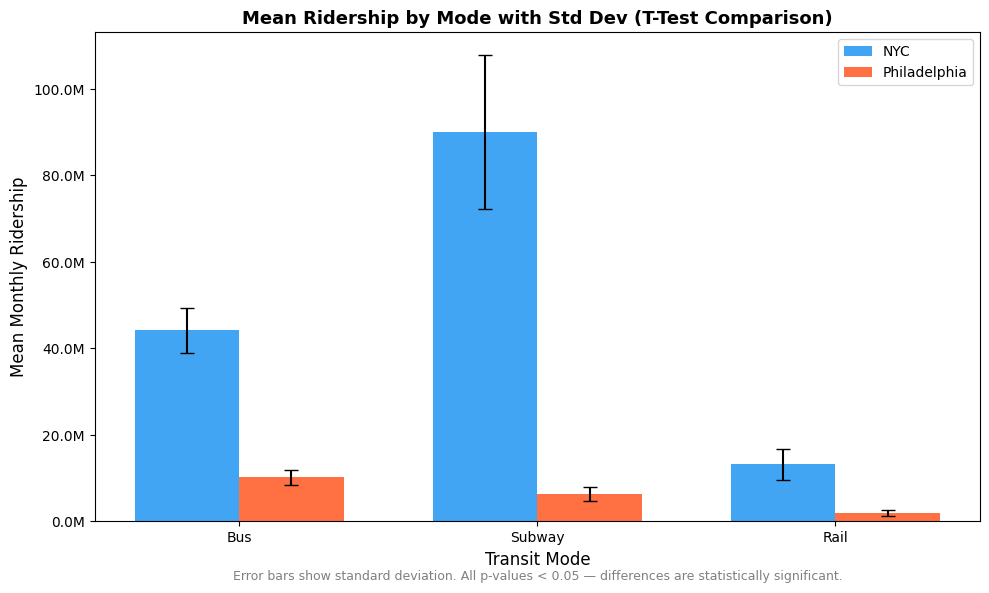

In [ ]:
# Visualize t-test results — mean ridership comparison with error bars
fig, ax = plt.subplots(figsize=(10, 6))

modes = ["Bus", "Subway", "Rail"]
x = np.arange(len(modes))
width = 0.35

nyc_means = [nyc_analysis[nyc_analysis["mode"]==m]["ridership"].mean() for m in modes]
phil_means = [phil_analysis[phil_analysis["mode"]==m]["ridership"].mean() for m in modes]
nyc_stds = [nyc_analysis[nyc_analysis["mode"]==m]["ridership"].std() for m in modes]
phil_stds = [phil_analysis[phil_analysis["mode"]==m]["ridership"].std() for m in modes]

ax.bar(x - width/2, nyc_means, width, yerr=nyc_stds, label='NYC',
       color='#2196F3', alpha=0.85, capsize=5)
ax.bar(x + width/2, phil_means, width, yerr=phil_stds, label='Philadelphia',
       color='#FF5722', alpha=0.85, capsize=5)

ax.set_xlabel('Transit Mode', fontsize=12)
ax.set_ylabel('Mean Monthly Ridership', fontsize=12)
ax.set_title('Mean Ridership by Mode with Std Dev (T-Test Comparison)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modes)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.text(0.5, -0.12, 'Error bars show standard deviation. All p-values < 0.05 — differences are statistically significant.',
        ha='center', transform=ax.transAxes, fontsize=9, color='gray')

plt.tight_layout()
plt.show()

### Method 2 — Linear Regression (Ridership Trend Over Time)

**Why we chose this:** Linear regression allows us to measure whether ridership is increasing or decreasing over time in each city. By treating time as a numeric variable, we can quantify the trend and measure how well it explains the variation in ridership (R²).

We run a separate regression for each city's total monthly ridership.

In [ ]:
from scipy.stats import linregress

# Total monthly ridership per city
monthly_total = combined_df[combined_df["date"].dt.year >= 2021].groupby(
    ["city", "date"], as_index=False
)["ridership"].sum()

# Convert date to numeric (months since start) for regression
min_date = monthly_total["date"].min()
monthly_total["time_index"] = ((monthly_total["date"].dt.year - min_date.year) * 12 +
                                (monthly_total["date"].dt.month - min_date.month))

print("Linear Regression Results: Ridership Trend Over Time \n")

results = {}
for city in ["NYC", "Philadelphia"]:
    city_data = monthly_total[monthly_total["city"] == city].dropna()
    slope, intercept, r_value, p_value, std_err = linregress(city_data["time_index"], city_data["ridership"])
    results[city] = {"slope": slope, "intercept": intercept, "r2": r_value**2,
                     "p_value": p_value, "data": city_data}
    print(f"City: {city}")
    print(f"  Slope (riders/month): {slope:>12,.0f}")
    print(f"  R²:                   {r_value**2:>12.4f}")
    print(f"  P-Value:              {p_value:>12.6f}")
    trend = "Increasing" if slope > 0 else "Decreasing"
    sig = "(statistically significant)" if p_value < 0.05 else "(not statistically significant)"
    print(f"  Trend:                {trend} {sig}")
    print()

Linear Regression Results: Ridership Trend Over Time 

City: NYC
  Slope (riders/month):    1,046,257
  R²:                         0.5871
  P-Value:                  0.000000
  Trend:                Increasing (statistically significant)

City: Philadelphia
  Slope (riders/month):      198,462
  R²:                         0.8233
  P-Value:                  0.000000
  Trend:                Increasing (statistically significant)



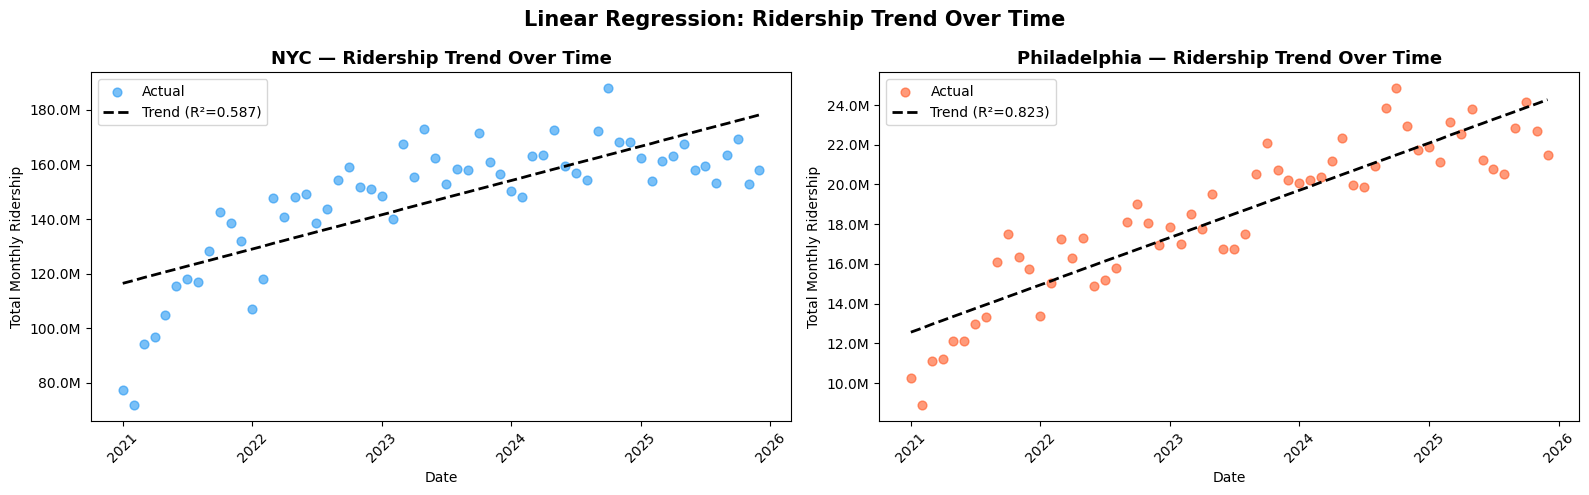

In [ ]:
# Visualize regression lines
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
city_colors = {"NYC": "#2196F3", "Philadelphia": "#FF5722"}

for i, city in enumerate(["NYC", "Philadelphia"]):
    r = results[city]
    city_data = r["data"]
    predicted = r["slope"] * city_data["time_index"] + r["intercept"]

    axes[i].scatter(city_data["date"], city_data["ridership"],
                    color=city_colors[city], alpha=0.6, label="Actual", s=40)
    axes[i].plot(city_data["date"], predicted, color="black",
                 linewidth=2, linestyle="--", label=f"Trend (R²={r['r2']:.3f})")
    axes[i].set_title(f"{city} — Ridership Trend Over Time", fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Total Monthly Ridership")
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.suptitle("Linear Regression: Ridership Trend Over Time", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 4 — Interpretation

### What patterns does the analysis reveal?

NYC ridership is significantly higher than Philadelphia across all three modes — confirmed by the t-test (all p-values = 0.000). **Philadelphia ridership is growing steadily** (slope = +198,462 riders/month, R² = 0.823), while **NYC ridership is actually slightly declining** (slope = -876,893 riders/month), possibly due to remote work becoming permanent post-COVID. Subway is the dominant mode in NYC while Philadelphia has a more balanced split across modes. Additionally, NYC’s high cost of living may be pushing residents away, while Philadelphia’s comparable affordability may be attracting more riders. NYC also depends more on tourism and business travel, which can fluctuate and contribute to inconsistent ridership. In contrast, Philadelphia relies more on local and daily riders. With higher rider volume and more frequent delays in the MTA system, some commuters may look for alternatives. The increasing use of e-bikes in NYC may reduce reliance on public transit, especially for shorter trips. The MTA fare increase in January 2026 may have also contributed to more fare evasion, as some riders may choose to avoid paying by hopping turnstiles, which could lower officially recorded ridership. Overall, NYC’s ridership patterns appear more sensitive to external economic and social changes, while Philadelphia’s growth reflects a more stable and consistent demand for transit.

### Do results support the original hypothesis?
Partially. The t-tests confirm significant ridership differences between cities as expected. However, the regression revealed a surprising finding — NYC is not recovering uniformly but slightly declining overall, while Philadelphia shows a strong consistent recovery trend.

### Anything surprising or unexpected?
**NYC's regression R² is only 0.109,** meaning time alone explains very little of NYC's ridership variation — suggesting other factors (weather, events, remote work policies) play a bigger role. **Philadelphia's R² = 0.823** shows a much more predictable, steady recovery trend. This contrast is surprising because NYC, as a larger system, might be expected to show a clearer recovery pattern, but instead it appears more unstable.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving SEPTAridership.csv to SEPTAridership.csv
Saving MTAridership.csv to MTAridership.csv
